<a href="https://colab.research.google.com/github/JennyDiones/ITELEC2_PROJECT/blob/MANZANILLO/Chapter9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/Colab Notebooks/climate_change_data.csv'

import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/climate_change_data.csv')

df = df.dropna()
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

Mounted at /content/drive


In [2]:
# remove missing values
df = df.dropna()

# convert date
df['Date'] = pd.to_datetime(df['Date'])

# feature engineering
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

In [3]:
df['FloodRisk'] = (df['Precipitation'] > 80).astype(int)

In [4]:
features = [
    'Temperature',
    'CO2 Emissions',
    'Sea Level Rise',
    'Humidity',
    'Wind Speed',
    'Year',
    'Month'
]

X = df[features]
y = df['FloodRisk']

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

In [6]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8065

Classification Report:

              precision    recall  f1-score   support

           0       0.81      1.00      0.89      1613
           1       0.00      0.00      0.00       387

    accuracy                           0.81      2000
   macro avg       0.40      0.50      0.45      2000
weighted avg       0.65      0.81      0.72      2000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


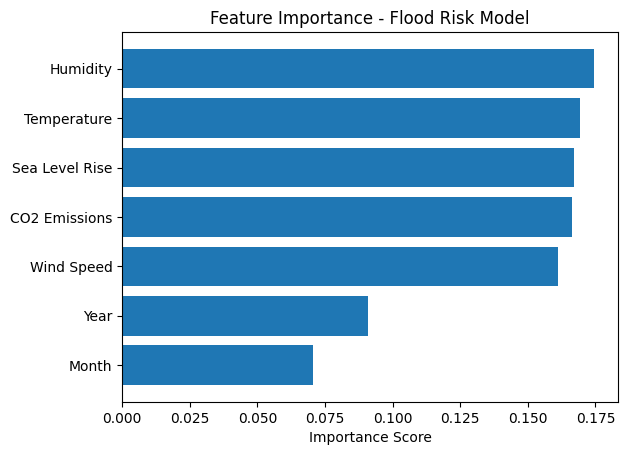

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

importances = model.feature_importances_

feat_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance')

plt.figure()
plt.barh(feat_df['Feature'], feat_df['Importance'])
plt.title("Feature Importance - Flood Risk Model")
plt.xlabel("Importance Score")
plt.show()

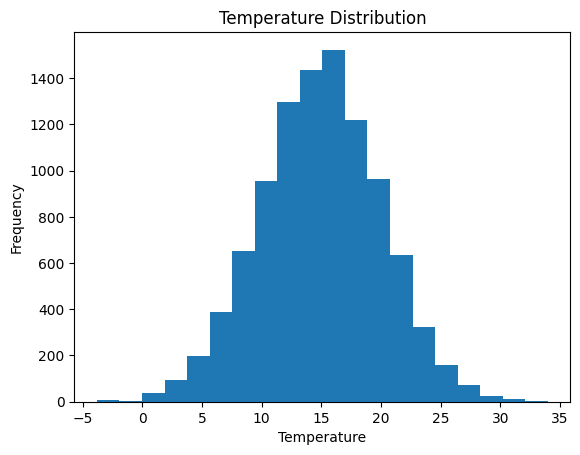

In [8]:
plt.figure()
plt.hist(df['Temperature'], bins=20)
plt.title("Temperature Distribution")
plt.xlabel("Temperature")
plt.ylabel("Frequency")
plt.show()

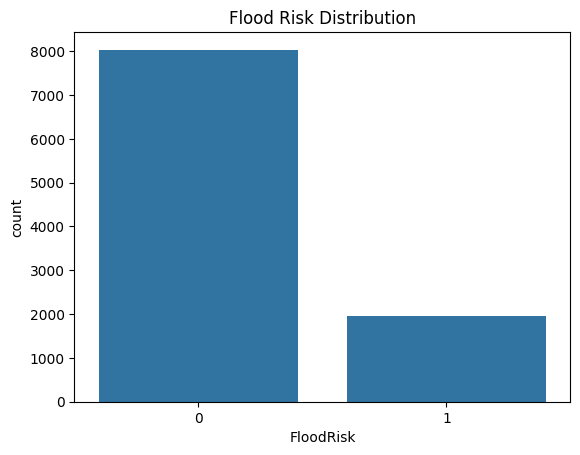

In [9]:
import seaborn as sns

plt.figure()
sns.countplot(x='FloodRisk', data=df)
plt.title("Flood Risk Distribution")
plt.show()

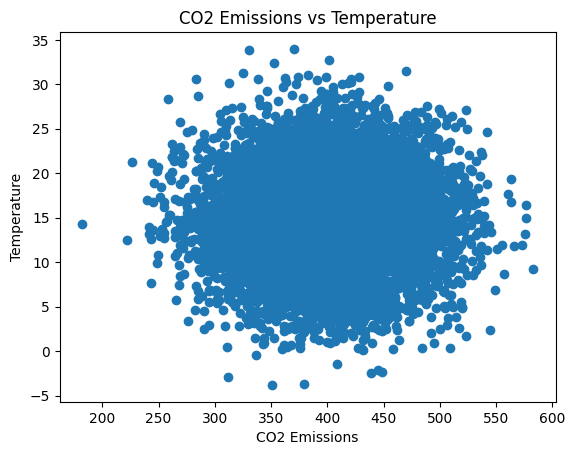

In [10]:
plt.figure()
plt.scatter(df['CO2 Emissions'], df['Temperature'])
plt.title("CO2 Emissions vs Temperature")
plt.xlabel("CO2 Emissions")
plt.ylabel("Temperature")
plt.show()